<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

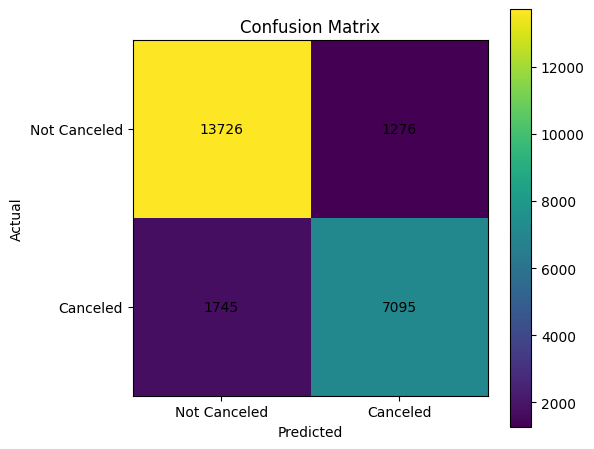

In [1]:
import pandas as pd
import os
import joblib
from src.data_cleaning import data_cleaning
from src.feature_engineering import feature_engineering
from src.preprocessing import preprocess
from src.model_training import train_model
from src.evaluation import evaluate_model



#load
path = os.path.join("data","hotel_bookings.csv")
df = pd.read_csv(path)

df.info()


# 2. Clean
df = data_cleaning(df)
df = feature_engineering(df)


from sklearn.model_selection import train_test_split
X = df.drop(columns = ["is_canceled"])
y = df["is_canceled"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


numerical_columns = [
    "lead_time",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "is_repeated_guest",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "total_guests","has_company"
]

categorical_columns = [
    "hotel",
    "arrival_season",
    "arrival_day_period",
    "country",
    "agent",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "deposit_type",
    "customer_type",
    "meal","arrival_date_year"
]


preprocessor = preprocess(
    numerical_columns,
    categorical_columns
)
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)




model = train_model(X_train, y_train)

os.makedirs("models", exist_ok=True)

joblib.dump(preprocessor, "models/preprocessor.pkl")
joblib.dump(model, "models/model.pkl")

results = evaluate_model(
    model,
    X_test,
    y_test
)

print("\n" + "=" * 40)
print("       MODEL EVALUATION RESULTS")
print("=" * 40)

for metric, value in results.items():
    if metric == "confusion_matrix":
        print(f"\n{metric.replace('_', ' ').title()}:")
        print(value)
    else:
        print(f"{metric.replace('_', ' ').title():<20}: {value:.4f}")

print("=" * 40)
import matplotlib.pyplot as plt

cm = results["confusion_matrix"]

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Not Canceled", "Canceled"])
plt.yticks([0, 1], ["Not Canceled", "Canceled"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

